In [13]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [14]:
jam_belajar_per_hari = 1
hari_kerja = 5
total_jam_sebulan = jam_belajar_per_hari * hari_kerja * 4

print(f"Target waktu belajar aku sebulan: {total_jam_sebulan} jam!")

Target waktu belajar aku sebulan: 20 jam!


In [15]:
import pandas as pd

data = {
    'produk': ['kopi', 'teh', 'roti', 'kopi', 'roti'],
    'harga': [15000, 10000, 12000, 15000, 12000],
    'jumlah_terjual': [5, 8, 3, 4, 6]
}

df = pd.DataFrame(data)
df



,produk,harga,jumlah_terjual
0,kopi,15000,5
1,teh,10000,8
2,roti,12000,3
3,kopi,15000,4
4,roti,12000,6


In [16]:
df['total'] = df['harga'] * df['jumlah_terjual']
df

,produk,harga,jumlah_terjual,total
0,kopi,15000,5,75000
1,teh,10000,8,80000
2,roti,12000,3,36000
3,kopi,15000,4,60000
4,roti,12000,6,72000


In [17]:
total_omzet = df['total'].sum()
print(f"Total Omzet Penjualan: Rp {total_omzet:,}")

Total Omzet Penjualan: Rp 323,000


In [18]:
penjualan_per_produk = df.groupby('produk')['total'].sum().reset_index()
penjualan_per_produk = penjualan_per_produk.sort_values(by='total', ascending=False)

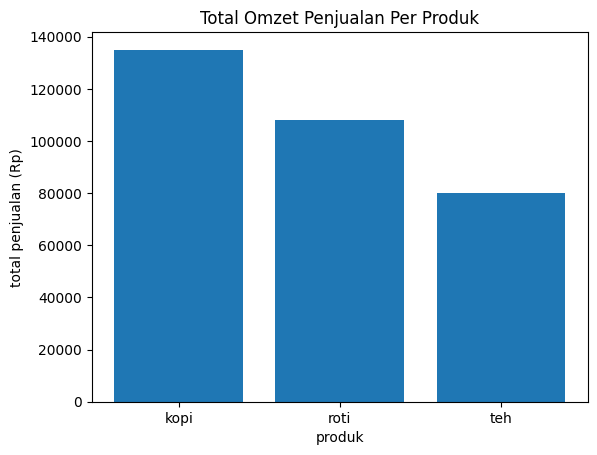

In [19]:
import matplotlib.pyplot as plt

plt.bar(penjualan_per_produk['produk'], penjualan_per_produk['total'])

plt.title('Total Omzet Penjualan Per Produk')
plt.xlabel('produk')
plt.ylabel('total penjualan (Rp)')
plt.show()

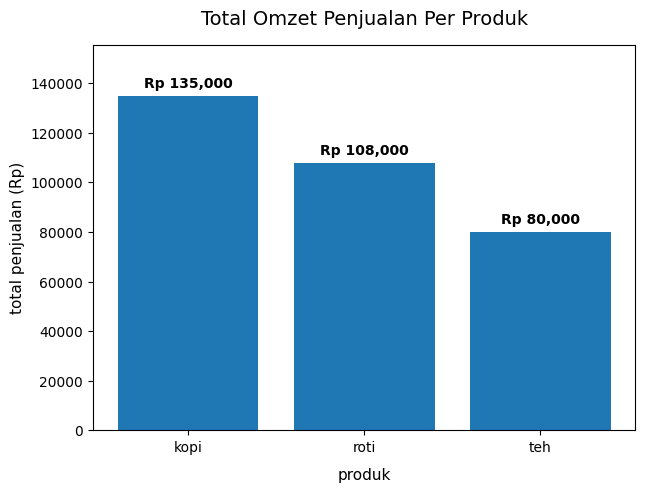

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

bars = plt.bar(penjualan_per_produk['produk'], penjualan_per_produk['total'], color='#1f77b4')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2000, f'Rp {int(yval):,}', ha='center', va='bottom', fontweight='bold')

plt.title('Total Omzet Penjualan Per Produk', fontsize=14, pad=15)
plt.xlabel('produk', fontsize=11, labelpad=10)
plt.ylabel('total penjualan (Rp)', fontsize=11)
plt.ylim(0, max(penjualan_per_produk['total']) * 1.15)
plt.savefig('grafik_penjualan.png', dpi=300, bbox_inches='tight')
plt.show()

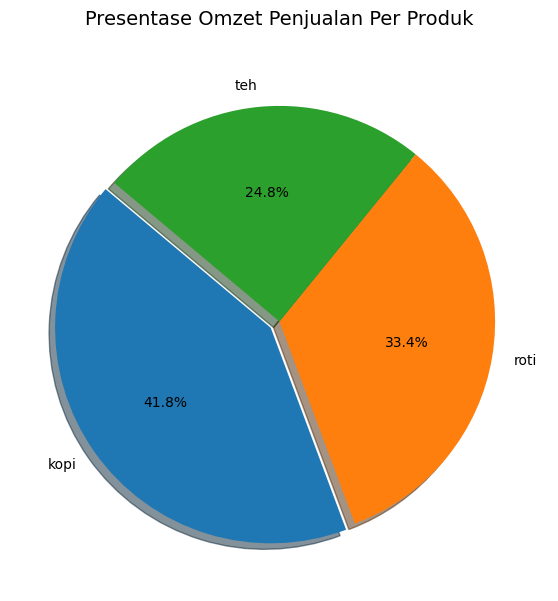

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

warna = ['#1f77b4', '#ff7f0e', '#2ca02c']

plt.pie(
    penjualan_per_produk['total'],
    labels=penjualan_per_produk['produk'],
    autopct='%1.1f%%',      
    startangle=140,
    colors=warna,
    explode=(0.05, 0, 0),
    shadow=True
)

plt.title('Presentase Omzet Penjualan Per Produk', fontsize=14, pad=20)

plt.savefig('pie_chart_penjualan.png', dpi=300, bbox_inches='tight')
plt.show()